Realizaremos el tercer modelo de predicción, tenemos que usar el dataset con las feature creadas pero sin normalizar para no alterar los datos y que el modelo funcione, por lo tanto usaremos el data set que se uso para el PowerBI

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Cargamos el featured (valores reales, no escalados)
df = pd.read_csv('/content/POWERBIecommerce_featured.csv')
df['order_date'] = pd.to_datetime(df['order_date'])

# Agrupar todas las órdenes por mes
# De 1500 filas individuales → 1 fila por mes
monthly = df.groupby(pd.Grouper(key='order_date', freq='MS')).agg(
    total_revenue   = ('total_amount', 'sum'),
    total_orders    = ('order_id', 'count'),
    avg_order_value = ('total_amount', 'mean'),
    avg_discount    = ('discount_pct', 'mean')
).reset_index()

print(monthly)
print(f"\nTotal de meses: {len(monthly)}")

   order_date  total_revenue  total_orders  avg_order_value  avg_discount
0  2022-01-01   33010.162500            58       569.140733      7.500000
1  2022-02-01   26976.703600            53       508.994408     10.283019
2  2022-03-01   39673.079000            57       696.018930      8.333333
3  2022-04-01   44189.097775            70       631.272825      9.142857
4  2022-05-01   47454.840860            62       765.400659      8.387097
5  2022-06-01   35725.551500            73       489.391116      9.178082
6  2022-07-01   41569.042540            64       649.516290     10.000000
7  2022-08-01   32529.073000            51       637.824961      7.647059
8  2022-09-01   32170.774000            59       545.267356     10.169492
9  2022-10-01   23379.789000            56       417.496232      8.839286
10 2022-11-01   46730.908410            72       649.040395      9.097222
11 2022-12-01   39465.579453            52       758.953451      6.826923
12 2023-01-01   44693.083400          

Creamos LEG FEATURES: diferencia clave entre un modelo normal y uno de series de tiempo, le dan al modelo memoria

In [8]:
# LAG FEATURES — "¿cuánto vendimos X meses atrás?"
monthly['lag_1'] = monthly['total_revenue'].shift(1)  # mes anterior
monthly['lag_2'] = monthly['total_revenue'].shift(2)  # hace 2 meses
monthly['lag_3'] = monthly['total_revenue'].shift(3)  # hace 3 meses

# ROLLING AVERAGES — "¿cuál es la tendencia reciente?"
monthly['rolling_3'] = monthly['total_revenue'].rolling(3).mean()
monthly['rolling_4'] = monthly['total_revenue'].rolling(4).mean()

# FEATURES DE TIEMPO — ya las tienes del Phase 5
monthly['month']     = monthly['order_date'].dt.month
monthly['quarter']   = monthly['order_date'].dt.quarter
monthly['year']      = monthly['order_date'].dt.year
monthly['month_sin'] = np.sin(2 * np.pi * monthly['month'] / 12)
monthly['month_cos'] = np.cos(2 * np.pi * monthly['month'] / 12)

# Eliminar los primeros meses que tienen NaN en los lags
# (los primeros 3 meses no tienen lag_1, lag_2, lag_3 completos)
monthly_clean = monthly.dropna().reset_index(drop=True)

print(f"Meses totales: {len(monthly)}")
print(f"Meses para modelar: {len(monthly_clean)}")
print(monthly_clean[['order_date','total_revenue','lag_1','lag_2','lag_3','rolling_3']].head(6))

Meses totales: 25
Meses para modelar: 22
  order_date  total_revenue         lag_1         lag_2         lag_3  \
0 2022-04-01   44189.097775  39673.079000  26976.703600  33010.162500   
1 2022-05-01   47454.840860  44189.097775  39673.079000  26976.703600   
2 2022-06-01   35725.551500  47454.840860  44189.097775  39673.079000   
3 2022-07-01   41569.042540  35725.551500  47454.840860  44189.097775   
4 2022-08-01   32529.073000  41569.042540  35725.551500  47454.840860   
5 2022-09-01   32170.774000  32529.073000  41569.042540  35725.551500   

      rolling_3  
0  36946.293458  
1  43772.339212  
2  42456.496712  
3  41583.144967  
4  36607.889013  
5  35422.963180  


Hacemos un Split temporal para evaluar el modelo

In [9]:

features_ts = ['lag_1', 'lag_2', 'lag_3',
               'rolling_3', 'rolling_4',
               'month', 'quarter',
               'month_sin', 'month_cos',
               'avg_discount', 'total_orders', 'avg_order_value']

X_ts = monthly_clean[features_ts]
y_ts = monthly_clean['total_revenue']

corte = -4  # últimos 4 meses como test

X_train_ts = X_ts.iloc[:corte]
X_test_ts  = X_ts.iloc[corte:]
y_train_ts = y_ts.iloc[:corte]
y_test_ts  = y_ts.iloc[corte:]

print(f"Train: {len(X_train_ts)} meses → el modelo APRENDE aquí")
print(f"Test:  {len(X_test_ts)} meses → el modelo es EVALUADO aquí")
print(f"\nFechas de test (predicciones):")
print(monthly_clean['order_date'].iloc[corte:].values)

Train: 18 meses → el modelo APRENDE aquí
Test:  4 meses → el modelo es EVALUADO aquí

Fechas de test (predicciones):
['2023-10-01T00:00:00.000000000' '2023-11-01T00:00:00.000000000'
 '2023-12-01T00:00:00.000000000' '2024-01-01T00:00:00.000000000']


Evaluamos el modelo

In [10]:
# Entrenar
forecaster = RandomForestRegressor(n_estimators=200, random_state=42)
forecaster.fit(X_train_ts, y_train_ts)

# Predecir
y_forecast = forecaster.predict(X_test_ts)

# Métricas
mae = mean_absolute_error(y_test_ts, y_forecast)
r2  = r2_score(y_test_ts, y_forecast)
print(f'MAE:      ${mae:,.2f}')
print(f'R2 Score: {r2:.4f}')

# Tabla comparativa real vs predicho
resultados = monthly_clean[['order_date','total_revenue']].iloc[corte:].copy()
resultados['predicted'] = y_forecast.round(2)
resultados['error_pct'] = (abs(resultados['total_revenue'] -
                           resultados['predicted']) /
                           resultados['total_revenue'] * 100).round(1)
print('\nReal vs Predicción:')
print(resultados.to_string(index=False))

MAE:      $19,170.86
R2 Score: -0.6883

Real vs Predicción:
order_date  total_revenue  predicted  error_pct
2023-10-01    22268.93517   34255.37       53.8
2023-11-01    19936.10400   32265.31       61.8
2023-12-01    54310.34850   42233.83       22.2
2024-01-01     6737.35500   47028.62      598.0


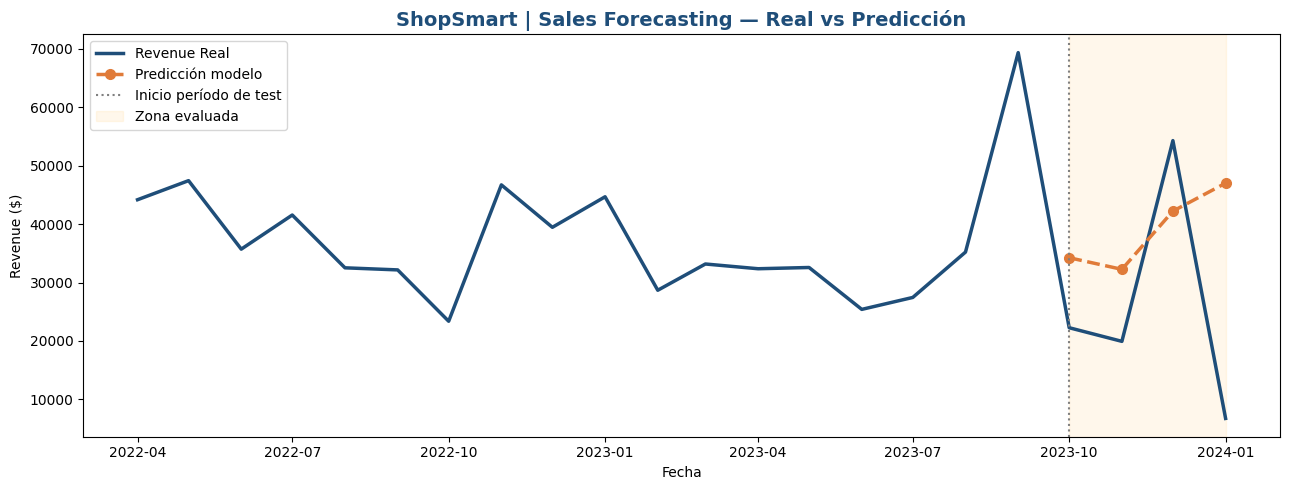

In [13]:
plt.figure(figsize=(13, 5))

# Línea de historia completa
plt.plot(monthly_clean['order_date'],
         monthly_clean['total_revenue'],
         label='Revenue Real', color='#1F4E79', linewidth=2.5)

# Línea de predicciones
plt.plot(monthly_clean['order_date'].iloc[corte:],
         y_forecast,
         label='Predicción modelo', color='#E07B39',
         linewidth=2.5, linestyle='--', marker='o', markersize=7)

# Línea divisoria
plt.axvline(x=monthly_clean['order_date'].iloc[corte],
            color='gray', linestyle=':', linewidth=1.5,
            label='Inicio período de test')

# Área sombreada del test
plt.axvspan(monthly_clean['order_date'].iloc[corte],
            monthly_clean['order_date'].iloc[-1],
            alpha=0.08, color='orange', label='Zona evaluada')

plt.title('ShopSmart | Sales Forecasting — Real vs Predicción',
          fontsize=14, fontweight='bold', color='#1F4E79')
plt.xlabel('Fecha')
plt.ylabel('Revenue ($)')
plt.legend()
plt.tight_layout()
import os
os.makedirs('charts', exist_ok=True)  # ← agrega esto
plt.savefig('charts/forecasting.png')
plt.show()